# SNN-PC Hybrid — Demo Notebook

Ce notebook illustre le fonctionnement du framework hybride SNN-Predictive Coding
avec l'architecture Broca-Wernicke.

## Contenu
1. Raster plot des trains de spikes (Wernicke & Broca)
2. Courbes F(t) et r(t) superposées
3. Comparaison convergence cyclique avec/sans amortissement
4. Inspection de la dynamique membranaire

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

from config import SNNConfig
from core import LIFNeuron, OscillatoryClock
from core.encoding import rate_encode, phase_encode
from modules import WernickeModule, BrocaModule, ArcuateFasciculus
from training.loss import variational_free_energy
from graph.phase_sync import compute_order_parameter, kuramoto_condition, kuramoto_update
from graph.pc_gnn import PCGNN

config = SNNConfig()
print(f'Device : {config.device}')
print(f'tau_m = {config.tau_m}ms, dt = {config.dt}ms')
print(f'theta = {config.theta_freq}Hz, gamma = {config.gamma_freq}Hz')

Device : cpu
tau_m = 20.0ms, dt = 0.1ms
theta = 6.0Hz, gamma = 40.0Hz


## 1. Raster plot des trains de spikes

On simule 500ms de dynamique pour les modules Wernicke et Broca
avec un input sémantique fixe.

In [2]:
VOCAB_SIZE = 46
N_DISPLAY = 24  # neurones affichés dans le raster
T_MS = 500      # durée de simulation en ms
N_STEPS = int(T_MS / config.dt)

wernicke = WernickeModule(VOCAB_SIZE, config)
broca = BrocaModule(VOCAB_SIZE, config)
arcuate = ArcuateFasciculus(config)
clock = OscillatoryClock(config)

# Input sémantique fixe (one-hot du mot 'chat')
subject_onehot = torch.zeros(1, VOCAB_SIZE)
subject_onehot[0, 9] = 1.0  # index de 'chat'
context = torch.tensor([1])  # BOS
mu_prior = torch.zeros(1, config.dim_wernicke)

spikes_W_all = []
spikes_B_all = []
F_history = []
r_history = []
phases = torch.rand(config.dim_broca) * 2 * np.pi

print(f'Simulation de {T_MS}ms ({N_STEPS} pas)...')

# Sous-échantillonner pour la visualisation (chaque 10 pas)
RECORD_EVERY = 10

for t in range(N_STEPS):
    clock.step()
    
    w_out = wernicke(subject_onehot, mu_prior, clock)
    msg_W2B, _ = arcuate.transmit(w_out['prediction'], 'W2B', ['W'])
    b_out = broca(msg_W2B, context, clock)
    
    if t % RECORD_EVERY == 0:
        spikes_W_all.append(w_out['spikes'][0, :N_DISPLAY].detach().numpy())
        spikes_B_all.append(b_out['spikes'][0, :N_DISPLAY].detach().numpy())
        
        F = variational_free_energy(w_out['epsilon'], b_out['epsilon']).item()
        F_history.append(F)
        
        W_phase = torch.eye(config.dim_broca) * 0.01
        phases = kuramoto_update(phases, W_phase, dt=config.dt * RECORD_EVERY)
        r = compute_order_parameter(phases)
        r_history.append(r)

spikes_W = np.array(spikes_W_all)  # (T_rec, N_DISPLAY)
spikes_B = np.array(spikes_B_all)
T_rec = spikes_W.shape[0]
time_ms = np.arange(T_rec) * config.dt * RECORD_EVERY

print(f'Taux moyen Wernicke : {spikes_W.mean():.4f} spikes/pas')
print(f'Taux moyen Broca    : {spikes_B.mean():.4f} spikes/pas')

Simulation de 500ms (5000 pas)...
Taux moyen Wernicke : 0.0301 spikes/pas
Taux moyen Broca    : 0.0230 spikes/pas


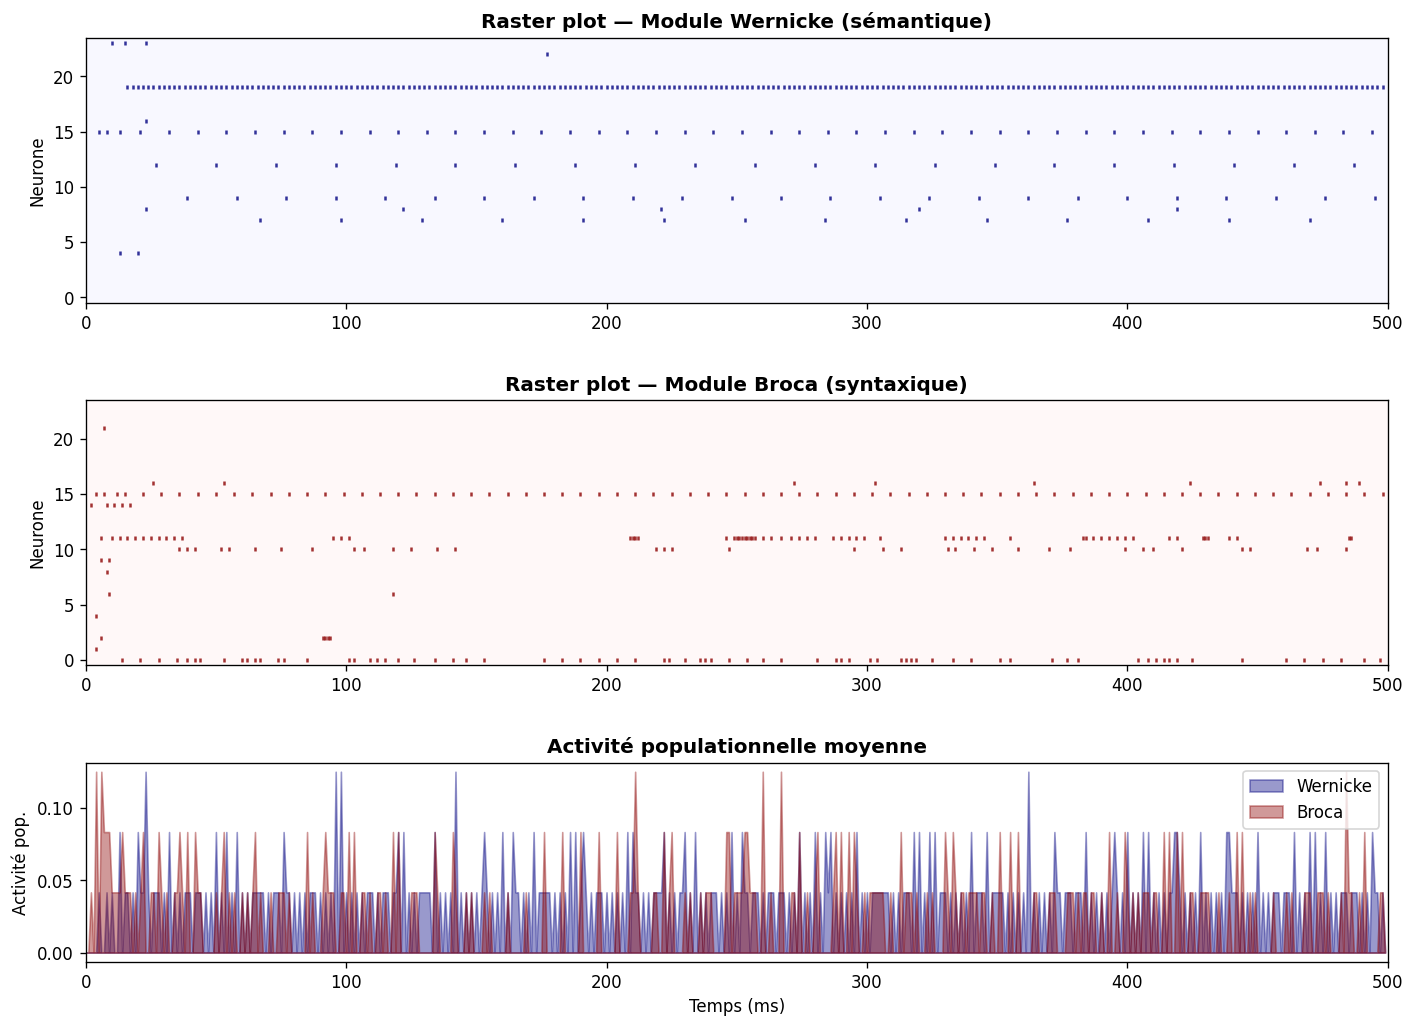

Figure sauvegardée : results/demo_raster_plot.png


In [3]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, height_ratios=[2, 2, 1.5], hspace=0.4)

# ── Raster Wernicke ───────────────────────────────────────────────────────────
ax_W = fig.add_subplot(gs[0])
for n in range(N_DISPLAY):
    spike_times = time_ms[spikes_W[:, n] > 0.5]
    ax_W.scatter(spike_times, np.full_like(spike_times, n),
                 s=5, c='navy', alpha=0.8, marker='|', linewidths=1.5)
ax_W.set_ylabel('Neurone')
ax_W.set_title('Raster plot — Module Wernicke (sémantique)', fontweight='bold')
ax_W.set_ylim(-0.5, N_DISPLAY - 0.5)
ax_W.set_xlim(0, T_MS)
ax_W.set_facecolor('#f8f8ff')

# ── Raster Broca ─────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])
for n in range(N_DISPLAY):
    spike_times = time_ms[spikes_B[:, n] > 0.5]
    ax_B.scatter(spike_times, np.full_like(spike_times, n),
                 s=5, c='darkred', alpha=0.8, marker='|', linewidths=1.5)
ax_B.set_ylabel('Neurone')
ax_B.set_title('Raster plot — Module Broca (syntaxique)', fontweight='bold')
ax_B.set_ylim(-0.5, N_DISPLAY - 0.5)
ax_B.set_xlim(0, T_MS)
ax_B.set_facecolor('#fff8f8')

# ── Activité populationnelle ──────────────────────────────────────────────────
ax_pop = fig.add_subplot(gs[2])
pop_W = spikes_W.mean(axis=1)
pop_B = spikes_B.mean(axis=1)
ax_pop.fill_between(time_ms, pop_W, alpha=0.4, color='navy', label='Wernicke')
ax_pop.fill_between(time_ms, pop_B, alpha=0.4, color='darkred', label='Broca')
ax_pop.set_xlabel('Temps (ms)')
ax_pop.set_ylabel('Activité pop.')
ax_pop.set_title('Activité populationnelle moyenne', fontweight='bold')
ax_pop.legend(loc='upper right')
ax_pop.set_xlim(0, T_MS)

plt.savefig('results/demo_raster_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : results/demo_raster_plot.png')

## 2. Énergie libre F(t) et paramètre d'ordre r(t)

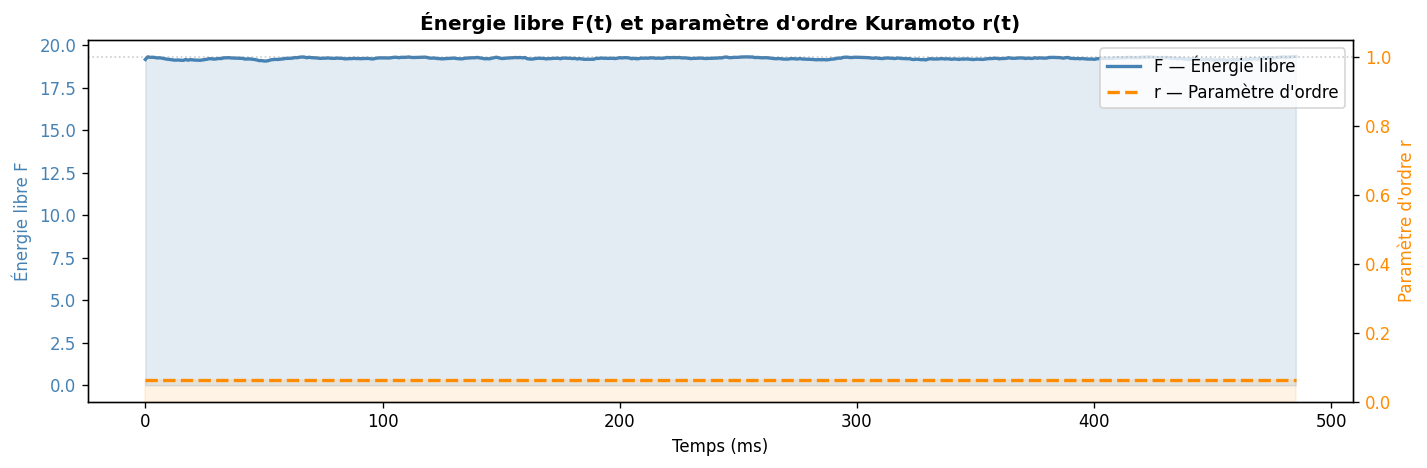

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# Lissage par moyenne glissante
def smooth(arr, window=10):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

F_smooth = smooth(F_history, window=15)
r_smooth = smooth(r_history, window=15)
t_smooth = time_ms[:len(F_smooth)]

color_F = 'steelblue'
ax1.plot(t_smooth, F_smooth, color=color_F, linewidth=2, label='F — Énergie libre')
ax1.fill_between(t_smooth, F_smooth, alpha=0.15, color=color_F)
ax1.set_xlabel('Temps (ms)')
ax1.set_ylabel('Énergie libre F', color=color_F)
ax1.tick_params(axis='y', labelcolor=color_F)
ax1.set_title('Énergie libre F(t) et paramètre d\'ordre Kuramoto r(t)', fontweight='bold')

ax2 = ax1.twinx()
color_r = 'darkorange'
ax2.plot(t_smooth, r_smooth, color=color_r, linewidth=2, linestyle='--',
         label='r — Paramètre d\'ordre')
ax2.fill_between(t_smooth, r_smooth, alpha=0.1, color=color_r)
ax2.set_ylabel('Paramètre d\'ordre r', color=color_r)
ax2.tick_params(axis='y', labelcolor=color_r)
ax2.set_ylim(0, 1.05)
ax2.axhline(y=1.0, color='gray', linestyle=':', alpha=0.4, linewidth=1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('results/demo_F_r_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparaison convergence cyclique — avec/sans amortissement

On compare la dynamique de convergence du PC-GNN sur un graphe cyclique
(Erdős–Rényi p=0.5) avec et sans l'amortissement cyclique du fascicule arqué.

In [5]:
N_NODES = 8
NODE_DIM = 16
N_SIM = 60

# Graphe Erdős-Rényi p=0.5
torch.manual_seed(42)
adj_er = (torch.rand(N_NODES, N_NODES) < 0.5).float()
adj_er.fill_diagonal_(0.0)
n_cycles = max(0, int(adj_er.sum().item() - N_NODES + 1))

print(f'Graphe E-R : {N_NODES} nœuds, {adj_er.sum().item():.0f} arêtes, ~{n_cycles} cycles')

# Vérification condition de Kuramoto
W_k = adj_er * 0.01
conv_ok, margin = kuramoto_condition(W_k, gamma=config.gamma_stability)
print(f'Condition Kuramoto : {"✓ OK" if conv_ok else "✗ FAIL"} (marge = {margin:.4f})')

def simulate(adj, damping_lambda, n_steps, node_dim):
    """Simule le PC-GNN et retourne l'historique F et r."""
    cfg = SNNConfig()
    cfg.cycle_damping_lambda = damping_lambda
    cfg.n_inference_steps = 5
    
    model = PCGNN(adj.shape[0], node_dim, cfg)
    x = torch.randn(adj.shape[0], node_dim)
    obs_mask = torch.zeros(adj.shape[0], dtype=torch.bool)
    obs_mask[:adj.shape[0]//3] = True
    edge_index = adj.nonzero(as_tuple=False).t()
    
    phases = torch.rand(adj.shape[0]) * 2 * np.pi
    F_hist, r_hist = [], []
    
    for _ in range(n_steps):
        with torch.no_grad():
            out = model(x, edge_index, obs_mask)
        F_hist.append(out['free_energy'].item())
        
        W_p = adj * 0.01
        phases = kuramoto_update(phases, W_p, dt=0.1)
        r_hist.append(compute_order_parameter(phases))
    
    return F_hist, r_hist

print('Simulation avec amortissement (λ=0.5)...')
F_with, r_with = simulate(adj_er, damping_lambda=0.5, n_steps=N_SIM, node_dim=NODE_DIM)

print('Simulation sans amortissement (λ=0.0)...')
F_without, r_without = simulate(adj_er, damping_lambda=0.0, n_steps=N_SIM, node_dim=NODE_DIM)

Graphe E-R : 8 nœuds, 22 arêtes, ~15 cycles
Condition Kuramoto : ✓ OK (marge = 0.0678)
Simulation avec amortissement (λ=0.5)...
Simulation sans amortissement (λ=0.0)...


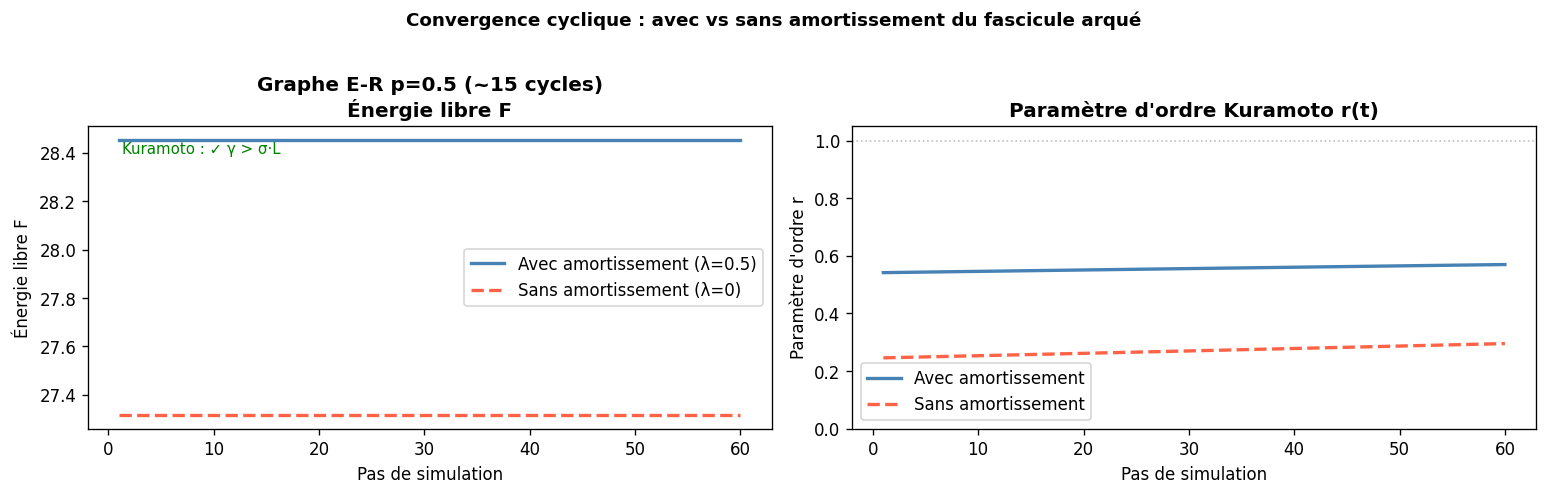

F finale (avec) : 28.4532
F finale (sans) : 27.3173
r final (avec)  : 0.5695
r final (sans)  : 0.2953


In [6]:
fig, (ax_F, ax_r) = plt.subplots(1, 2, figsize=(13, 4))
steps = list(range(1, N_SIM + 1))

# ── Énergie libre ─────────────────────────────────────────────────────────────
ax_F.plot(steps, F_with, color='steelblue', linewidth=2, label='Avec amortissement (λ=0.5)')
ax_F.plot(steps, F_without, color='tomato', linewidth=2, linestyle='--',
          label='Sans amortissement (λ=0)')
ax_F.set_xlabel('Pas de simulation')
ax_F.set_ylabel('Énergie libre F')
ax_F.set_title(f'Graphe E-R p=0.5 (~{n_cycles} cycles)\nÉnergie libre F', fontweight='bold')
ax_F.legend()

# Annotation condition de Kuramoto
ok_str = f'Kuramoto : {"✓ γ > σ·L" if conv_ok else "✗ γ ≤ σ·L"}'
ax_F.text(0.05, 0.95, ok_str, transform=ax_F.transAxes,
          color='green' if conv_ok else 'red', fontsize=9, verticalalignment='top')

# ── Paramètre d'ordre r ───────────────────────────────────────────────────────
ax_r.plot(steps, r_with, color='steelblue', linewidth=2, label='Avec amortissement')
ax_r.plot(steps, r_without, color='tomato', linewidth=2, linestyle='--',
          label='Sans amortissement')
ax_r.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax_r.set_xlabel('Pas de simulation')
ax_r.set_ylabel('Paramètre d\'ordre r')
ax_r.set_title('Paramètre d\'ordre Kuramoto r(t)', fontweight='bold')
ax_r.set_ylim(0, 1.05)
ax_r.legend()

plt.suptitle('Convergence cyclique : avec vs sans amortissement du fascicule arqué',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/demo_cyclic_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'F finale (avec) : {F_with[-1]:.4f}')
print(f'F finale (sans) : {F_without[-1]:.4f}')
print(f'r final (avec)  : {r_with[-1]:.4f}')
print(f'r final (sans)  : {r_without[-1]:.4f}')

## 4. Dynamique membranaire LIF

Visualisation du potentiel membranaire d'un neurone LIF unique
sous différentes conditions d'erreur de prédiction PC.

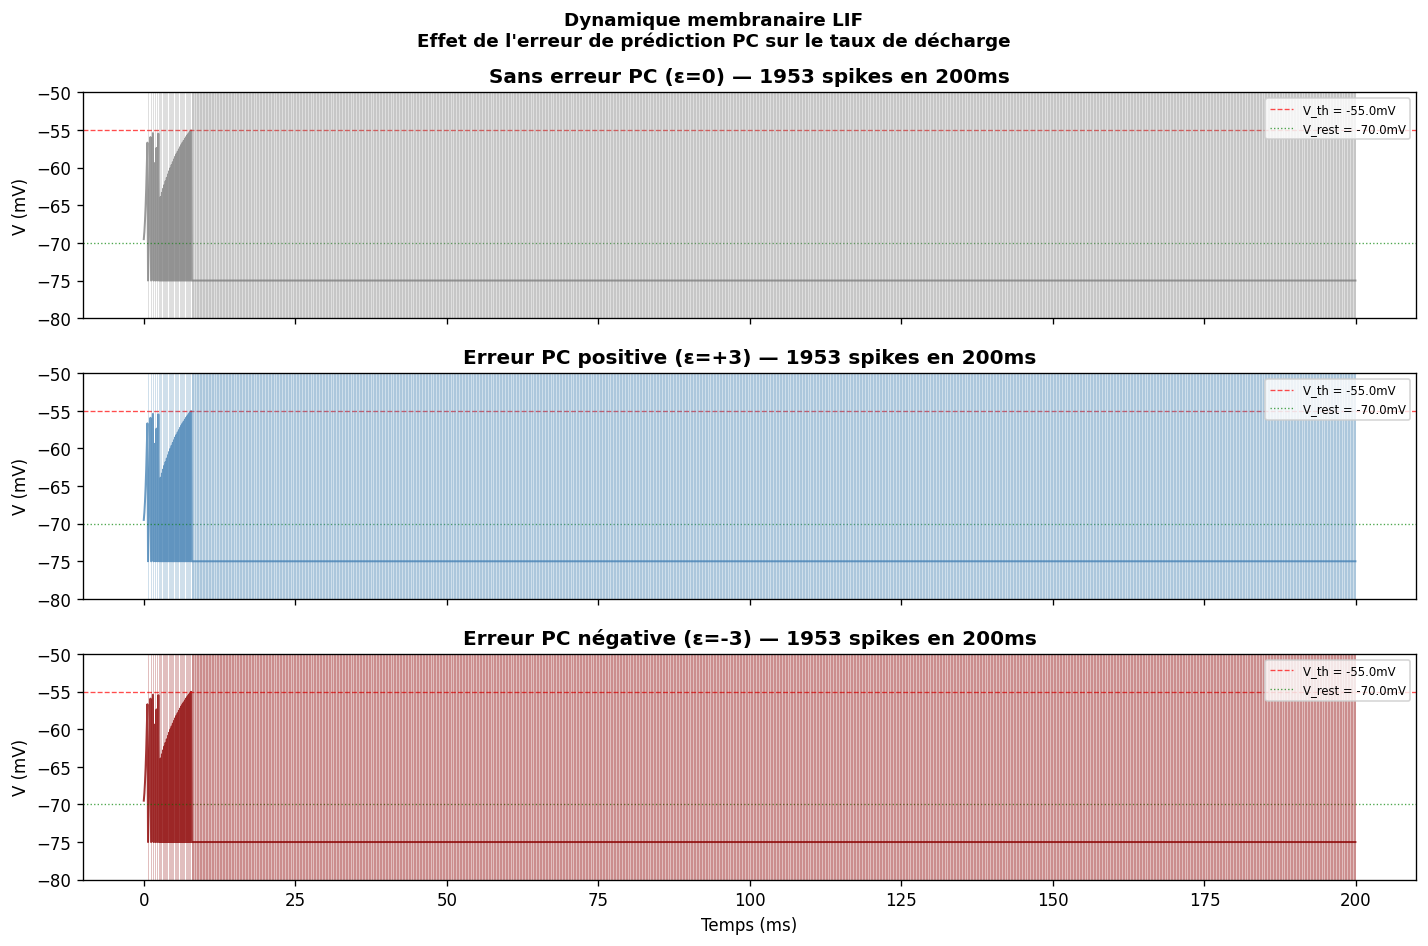

In [7]:
N_NEURONS = 1
T_SIM = int(200 / config.dt)  # 200ms

from core.neuron import LIFNeuron

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
conditions = [
    ('Sans erreur PC (ε=0)', torch.zeros(1, 1), 'gray'),
    ('Erreur PC positive (ε=+3)', torch.full((1, 1), 3.0), 'steelblue'),
    ('Erreur PC négative (ε=-3)', torch.full((1, 1), -3.0), 'darkred'),
]

time_axis = np.arange(T_SIM) * config.dt

for ax, (label, epsilon_val, color) in zip(axes, conditions):
    neuron = LIFNeuron(N_NEURONS, config)
    neuron.reset_state()
    
    V_trace = []
    spike_times = []
    
    I_syn = torch.zeros(1, N_NEURONS) + 5.0  # courant de base
    clk = OscillatoryClock(config)
    
    for t in range(T_SIM):
        clk.step()
        with torch.no_grad():
            spikes, V = neuron(I_syn, epsilon_val, clk.get_gamma_phase())
        V_trace.append(V[0, 0].item())
        if spikes[0, 0].item() > 0.5:
            spike_times.append(t * config.dt)
    
    ax.plot(time_axis, V_trace, color=color, linewidth=1.2, alpha=0.8)
    ax.axhline(y=config.v_threshold, color='red', linestyle='--', 
               linewidth=0.8, alpha=0.7, label=f'V_th = {config.v_threshold}mV')
    ax.axhline(y=config.v_rest, color='green', linestyle=':', 
               linewidth=0.8, alpha=0.7, label=f'V_rest = {config.v_rest}mV')
    
    # Marquer les spikes
    for st in spike_times:
        ax.axvline(x=st, color=color, linewidth=0.5, alpha=0.3)
    
    n_spikes = len(spike_times)
    ax.set_ylabel('V (mV)')
    ax.set_title(f'{label} — {n_spikes} spikes en 200ms', fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
    ax.set_ylim(config.v_reset - 5, config.v_threshold + 5)

axes[-1].set_xlabel('Temps (ms)')
plt.suptitle('Dynamique membranaire LIF\nEffet de l\'erreur de prédiction PC sur le taux de décharge',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('results/demo_membrane_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Encodage de phase

Illustration du codage temporel : les neurones avec grande erreur spikent
tôt dans le cycle gamma, ceux avec petite erreur spikent tard.

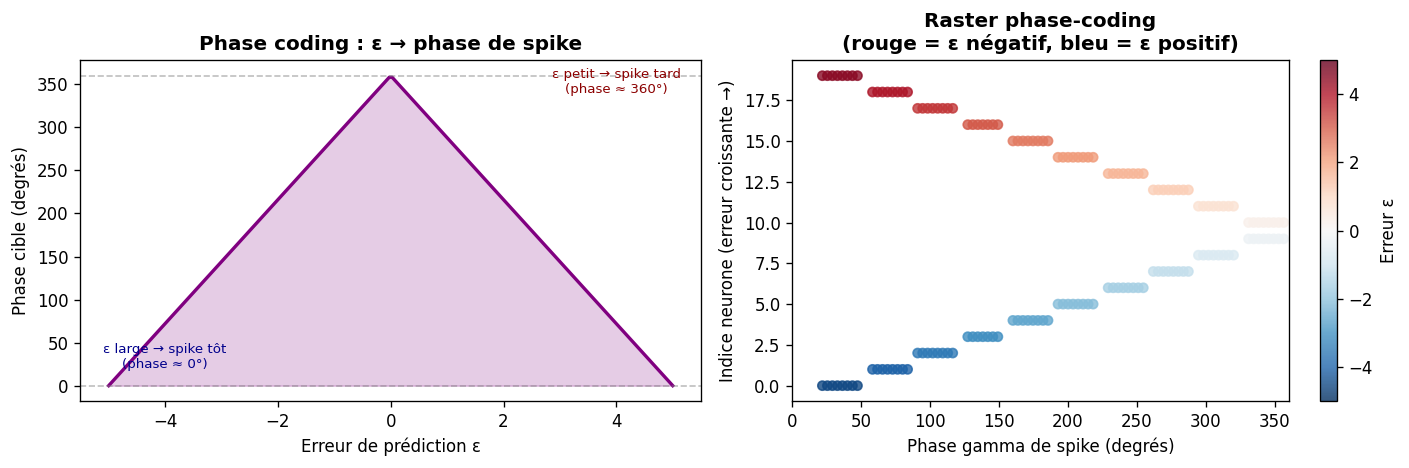

Demo complet ! Figures sauvegardées dans results/


In [8]:
import math

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Relation phase cible / erreur ─────────────────────────────────────────────
epsilon_vals = np.linspace(-5, 5, 200)
epsilon_norm = np.clip(np.abs(epsilon_vals) / 5.0, 0, 1)
phase_target = 2 * np.pi * (1 - epsilon_norm)  # en radians
phase_target_deg = np.degrees(phase_target)     # en degrés

ax1.plot(epsilon_vals, phase_target_deg, color='purple', linewidth=2)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=360, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_xlabel('Erreur de prédiction ε')
ax1.set_ylabel('Phase cible (degrés)')
ax1.set_title('Phase coding : ε → phase de spike', fontweight='bold')
ax1.fill_between(epsilon_vals, phase_target_deg, alpha=0.2, color='purple')
ax1.annotate('ε large → spike tôt\n(phase ≈ 0°)', xy=(-4, 20), fontsize=8,
             color='darkblue', ha='center')
ax1.annotate('ε petit → spike tard\n(phase ≈ 360°)', xy=(4, 340), fontsize=8,
             color='darkred', ha='center')

# ── Simulation de phase coding ─────────────────────────────────────────────────
N_NEURONS = 20
epsilon_test = torch.linspace(-4.5, 4.5, N_NEURONS).unsqueeze(0)  # (1, 20)

spike_times_phase = []
gamma_phases = np.linspace(0, 2 * np.pi, 100)

for neuron_idx in range(N_NEURONS):
    eps_n = epsilon_test[0, neuron_idx].item()
    for phase_val in gamma_phases:
        spikes = phase_encode(epsilon_test[:, neuron_idx:neuron_idx+1],
                              phase=phase_val, epsilon_max=5.0, alpha=0.5)
        if spikes.item() > 0.5:
            spike_times_phase.append((np.degrees(phase_val), neuron_idx, eps_n))

if spike_times_phase:
    phases_deg = [s[0] for s in spike_times_phase]
    neurons = [s[1] for s in spike_times_phase]
    eps_vals = [s[2] for s in spike_times_phase]
    
    sc = ax2.scatter(phases_deg, neurons, c=eps_vals, cmap='RdBu_r',
                     s=30, alpha=0.8, vmin=-5, vmax=5)
    plt.colorbar(sc, ax=ax2, label='Erreur ε')
    ax2.set_xlabel('Phase gamma de spike (degrés)')
    ax2.set_ylabel('Indice neurone (erreur croissante →)')
    ax2.set_title('Raster phase-coding\n(rouge = ε négatif, bleu = ε positif)', fontweight='bold')
    ax2.set_xlim(0, 360)

plt.tight_layout()
plt.savefig('results/demo_phase_coding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Demo complet ! Figures sauvegardées dans results/')